In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path("/scratch2/ij292/tnp-crps")
RESULT_DIR = repo_root / "results" / "synthetic_1d" / "student_t_df3_eval_full"
OUT_DIR = RESULT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = RESULT_DIR / "metrics.csv"
metrics = pd.read_csv(metrics_path)

print(metrics_path)
print(metrics.shape)
metrics.head()

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/metrics.csv
(36, 165)


,model_name,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,energy_score,ensemble_spread,...,rank_055_prob,rank_056_prob,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob
0,student_t_df3_dropout_crps_m4_p010,student_t_df3,all,all,64,524288,1.108940,0.417534,6.685480,1.109298,...,0.014772,0.014816,0.014742,0.014751,0.014645,0.014561,0.014462,0.014397,0.014400,0.014256
1,student_t_df3_dropout_crps_m4_p010,student_t_df3,all,nc_001_004,64,24576,1.509298,0.709284,10.190861,1.439813,...,0.014933,0.014893,0.014689,0.014608,0.014404,0.014730,0.013143,0.014079,0.015584,0.015828
2,student_t_df3_dropout_crps_m4_p010,student_t_df3,all,nc_005_016,64,102400,1.233921,0.525066,8.023357,1.277776,...,0.014873,0.015420,0.015029,0.015342,0.014971,0.015156,0.015596,0.015576,0.016016,0.016436
3,student_t_df3_dropout_crps_m4_p010,student_t_df3,all,nc_017_064,64,397312,1.043764,0.371773,6.123839,1.036714,...,0.014737,0.014656,0.014671,0.014608,0.014575,0.014397,0.014251,0.014112,0.013911,0.013596
4,student_t_df3_dropout_crps_m4_p010,student_t_df3,extrapolation,all,64,262065,1.435995,0.611152,6.076504,1.432719,...,0.014489,0.014760,0.014531,0.014470,0.014668,0.014531,0.014378,0.014397,0.015095,0.015218


In [2]:
MODEL_ORDER = [
    "student_t_df3_gaussian_tnp_nll",
    "student_t_df3_dropout_crps_m4_p010",
    "student_t_df3_stochln_crps_m4",
]

MODEL_LABELS = {
    "student_t_df3_gaussian_tnp_nll": "Gaussian TNP NLL",
    "student_t_df3_dropout_crps_m4_p010": "Dropout CRPS M=4 p=.10",
    "student_t_df3_stochln_crps_m4": "StochLN CRPS M=4",
}

def add_labels(df):
    out = df.copy()
    out["Model"] = out["model_name"].map(MODEL_LABELS).fillna(out["model_name"])
    out["model_order"] = out["model_name"].map({m: i for i, m in enumerate(MODEL_ORDER)})
    return out.sort_values("model_order")

overall = metrics.query(
    "region == 'all' and context_bucket == 'all'"
).copy()

overall = add_labels(overall)

cols = [
    "Model",
    "rmse_pooled",
    "crps",
    "energy_score",
    "spread_skill_ratio",
    "coverage_90",
    "coverage_95",
    "width_90",
    "width_95",
]

table = overall[cols].rename(
    columns={
        "rmse_pooled": "RMSE ↓",
        "crps": "CRPS ↓",
        "energy_score": "Energy ↓",
        "spread_skill_ratio": "SSR ≈ 1",
        "coverage_90": "Cov90",
        "coverage_95": "Cov95",
        "width_90": "Width90 ↓",
        "width_95": "Width95 ↓",
    }
)

for col in table.columns:
    if col != "Model":
        table[col] = table[col].round(3)

table

,Model,RMSE ↓,CRPS ↓,Energy ↓,SSR ≈ 1,Cov90,Cov95,Width90 ↓,Width95 ↓
12,Gaussian TNP NLL,1.098,0.411,6.606,0.999,0.877,0.923,2.307,2.700
0,Dropout CRPS M=4 p=.10,1.109,0.418,6.685,1.008,0.883,0.931,2.369,2.860
24,StochLN CRPS M=4,1.118,0.424,7.096,1.066,0.881,0.930,2.474,2.998


In [ ]:
def save_table_png(df, title, output_path, font_size=10, scale_y=1.35):
    fig_width = max(9, 1.25 * len(df.columns))
    fig_height = max(2.2, 0.45 * len(df) + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=14, pad=14)

    tab = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    tab.auto_set_font_size(False)
    tab.set_fontsize(font_size)
    tab.scale(1.0, scale_y)

    for (row, col), cell in tab.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eeeeee")

    fig.tight_layout()
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

save_table_png(
    table,
    "Student-t process df=3 results",
    OUT_DIR / "student_t_df3_results_table.png",
)

In [3]:
BUCKET_ORDER = ["nc_001_004", "nc_005_016", "nc_017_064"]
BUCKET_LABELS = {
    "nc_001_004": "1–4",
    "nc_005_016": "5–16",
    "nc_017_064": "17–64",
}

bucket_df = metrics.query(
    "region == 'all' and context_bucket != 'all'"
).copy()

bucket_df = add_labels(bucket_df)
bucket_df["bucket_order"] = bucket_df["context_bucket"].map(
    {b: i for i, b in enumerate(BUCKET_ORDER)}
)
bucket_df["Context points"] = bucket_df["context_bucket"].map(BUCKET_LABELS)
bucket_df = bucket_df.sort_values(["model_order", "bucket_order"])

bucket_df[[
    "Model",
    "Context points",
    "rmse_pooled",
    "crps",
    "energy_score",
    "spread_skill_ratio",
    "coverage_90",
    "coverage_95",
    "width_90",
    "width_95",
]]

,Model,Context points,rmse_pooled,crps,energy_score,spread_skill_ratio,coverage_90,coverage_95,width_90,width_95
13,Gaussian TNP NLL,1–4,1.508201,0.709546,10.189338,0.959327,0.883219,0.922363,3.975559,4.652264
14,Gaussian TNP NLL,5–16,1.212096,0.518051,7.945295,1.051339,0.877686,0.919219,2.943438,3.443701
15,Gaussian TNP NLL,17–64,1.034521,0.364720,6.038941,0.984832,0.876925,0.923722,2.040249,2.387609
1,Dropout CRPS M=4 p=.10,1–4,1.509298,0.709284,10.190861,0.961386,0.874674,0.923421,3.901471,4.780608
2,Dropout CRPS M=4 p=.10,5–16,1.233921,0.525066,8.023357,1.043600,0.872568,0.923770,2.970767,3.612988
3,Dropout CRPS M=4 p=.10,17–64,1.043764,0.371773,6.123839,1.000976,0.885954,0.932680,2.119524,2.546606
25,StochLN CRPS M=4,1–4,1.506443,0.712605,10.838720,0.964613,0.865804,0.919840,3.899242,4.774998
26,StochLN CRPS M=4,5–16,1.229609,0.533001,8.532928,1.096093,0.867285,0.919873,3.053746,3.702300
27,StochLN CRPS M=4,17–64,1.058218,0.377891,6.493737,1.068068,0.886087,0.933231,2.235999,2.707103


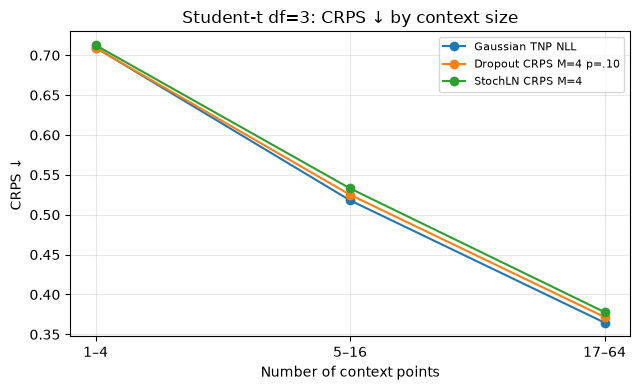

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/figures/student_t_df3_crps_by_context.png


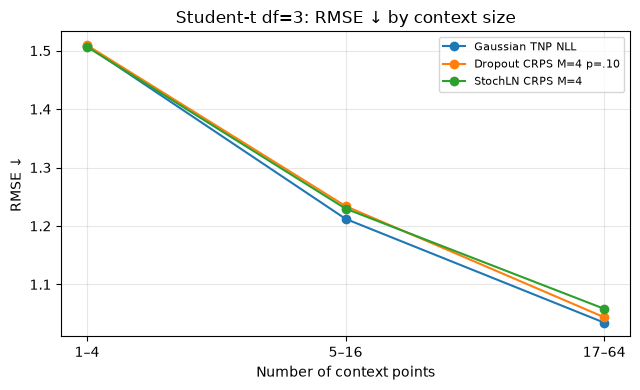

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/figures/student_t_df3_rmse_by_context.png


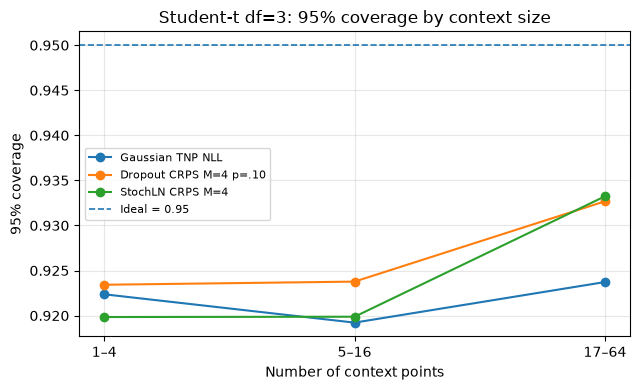

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/figures/student_t_df3_cov95_by_context.png


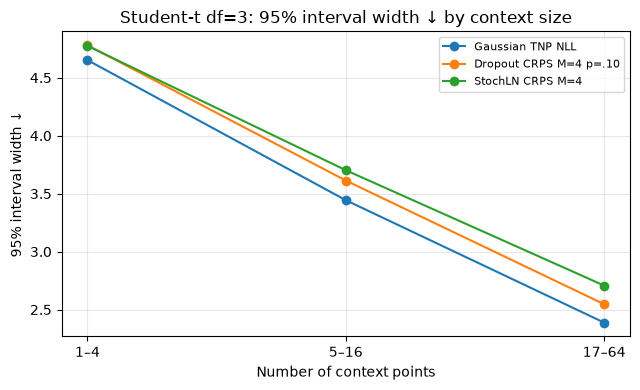

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/figures/student_t_df3_width95_by_context.png


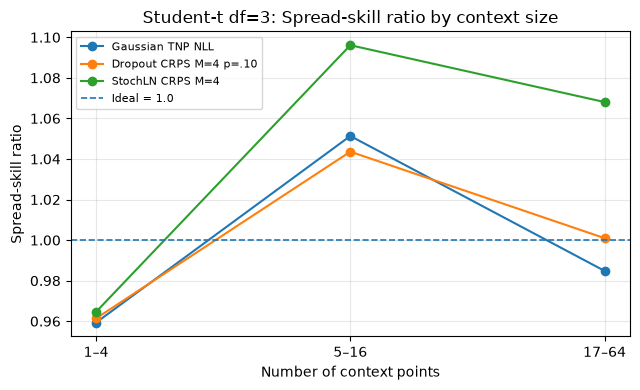

/scratch2/ij292/tnp-crps/results/synthetic_1d/student_t_df3_eval_full/figures/student_t_df3_ssr_by_context.png


In [4]:
def plot_metric_by_context(metric, ylabel, filename, ideal=None):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    for model_name in MODEL_ORDER:
        sub = bucket_df[bucket_df["model_name"] == model_name].sort_values("bucket_order")
        if sub.empty:
            continue

        ax.plot(
            sub["Context points"],
            sub[metric],
            marker="o",
            label=MODEL_LABELS.get(model_name, model_name),
        )

    if ideal is not None:
        ax.axhline(ideal, linestyle="--", linewidth=1.2, label=f"Ideal = {ideal}")

    ax.set_xlabel("Number of context points")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Student-t df=3: {ylabel} by context size")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()

    path = OUT_DIR / filename
    fig.savefig(path, dpi=250, bbox_inches="tight")
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    print(path)

plot_metric_by_context("crps", "CRPS ↓", "student_t_df3_crps_by_context.png")
plot_metric_by_context("rmse_pooled", "RMSE ↓", "student_t_df3_rmse_by_context.png")
plot_metric_by_context("coverage_95", "95% coverage", "student_t_df3_cov95_by_context.png", ideal=0.95)
plot_metric_by_context("width_95", "95% interval width ↓", "student_t_df3_width95_by_context.png")
plot_metric_by_context("spread_skill_ratio", "Spread-skill ratio", "student_t_df3_ssr_by_context.png", ideal=1.0)